In [1]:
library(tidyverse)
library(forecast)

#-----------------
options(
    repr.plot.width = 14,
    repr.plot.height = 9
)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.2.1     v readr     2.2.0
v forcats   1.0.1     v stringr   1.6.0
v ggplot2   4.0.3     v tibble    3.3.1
v lubridate 1.9.5     v tidyr     1.3.2
v purrr     1.2.2     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Load and pre-process data from [Danmarks Statistik](https://www.dst.dk/da/)

In [2]:
data_full <- read.csv("data_danmarks_statistik/danish_milk_production.csv", na = '..')

In [3]:
glimpse(data_full)

Rows: 372
Columns: 16
$ date                                                                                       <chr> ~
$ Milk.ex.farm..total..m.kg.                                                                 <dbl> ~
$ Delivered.milk.to.dairies..m.kg.                                                           <dbl> ~
$ Delivered.organic.milk.to.dairies..m.kg.                                                   <dbl> ~
$ Avarage.fat.content.of.delivered.milk.to.the.dairies..percent.                             <dbl> ~
$ Avarage.protein.content.of.delivered.milk.to.dairies..percent.                             <dbl> ~
$ Milk.ex.farm..total..DK.ore.per.kg.                                                        <dbl> ~
$ Milk.ex.farm.with.4.2..fat.content.and.3.4.protein.content..DK.ore.pr..kg.                 <dbl> ~
$ Milk.ex.farm..total..DKK.Mio.                                                              <dbl> ~
$ Production.of.butter..m.kg.                                        

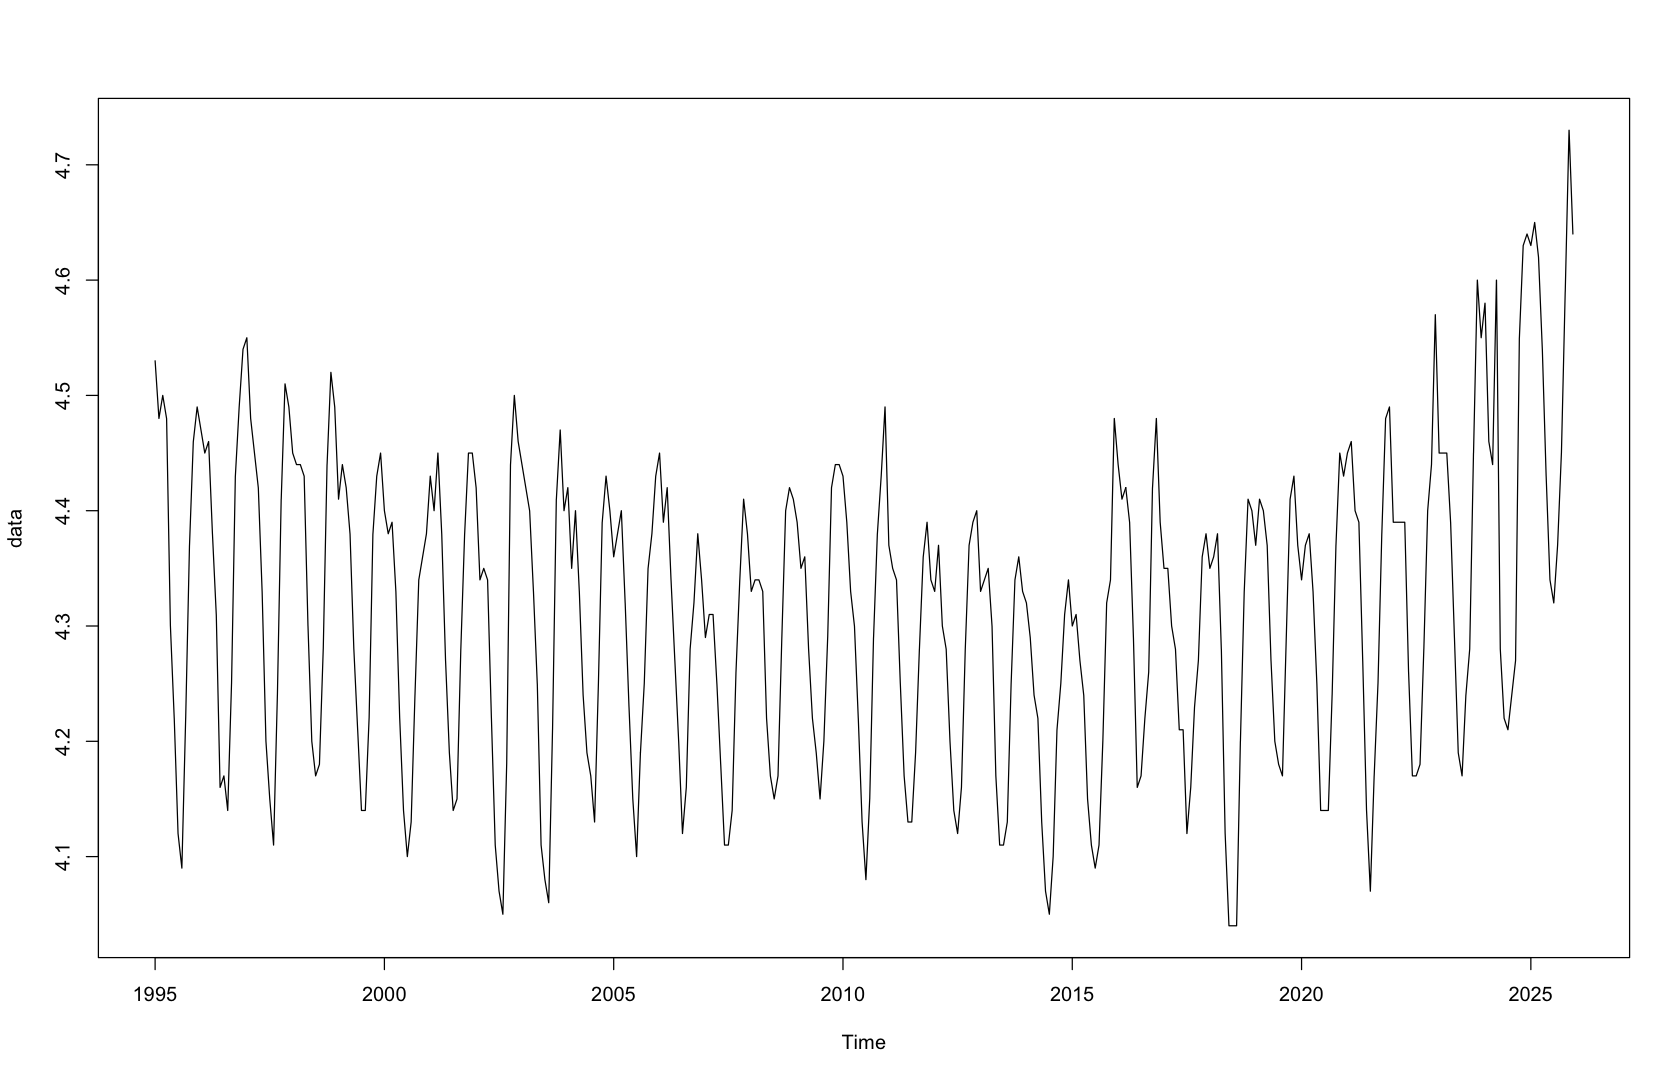

In [4]:
data <- ts(data_full$Avarage.fat.content.of.delivered.milk.to.the.dairies..percent.,
                start = c(1995, 1),
                frequency = 12,
                )

#--------------------------------------------------------
# Crop the data if needed
# data <- window(data, start = 2007)

# Log-transform if variance changes with time
# data <- log(data)

plot(data)

## Split into training and testing data (for forecasting), 95% and 5%, respectively

In [5]:
n <- length(data)
n_train <- floor(0.95 * n) # 95% of the data are training data
#---------------
data_train <- window(data, end = time(data)[n_train])
data_test  <- window(data, start = time(data)[n_train + 1])

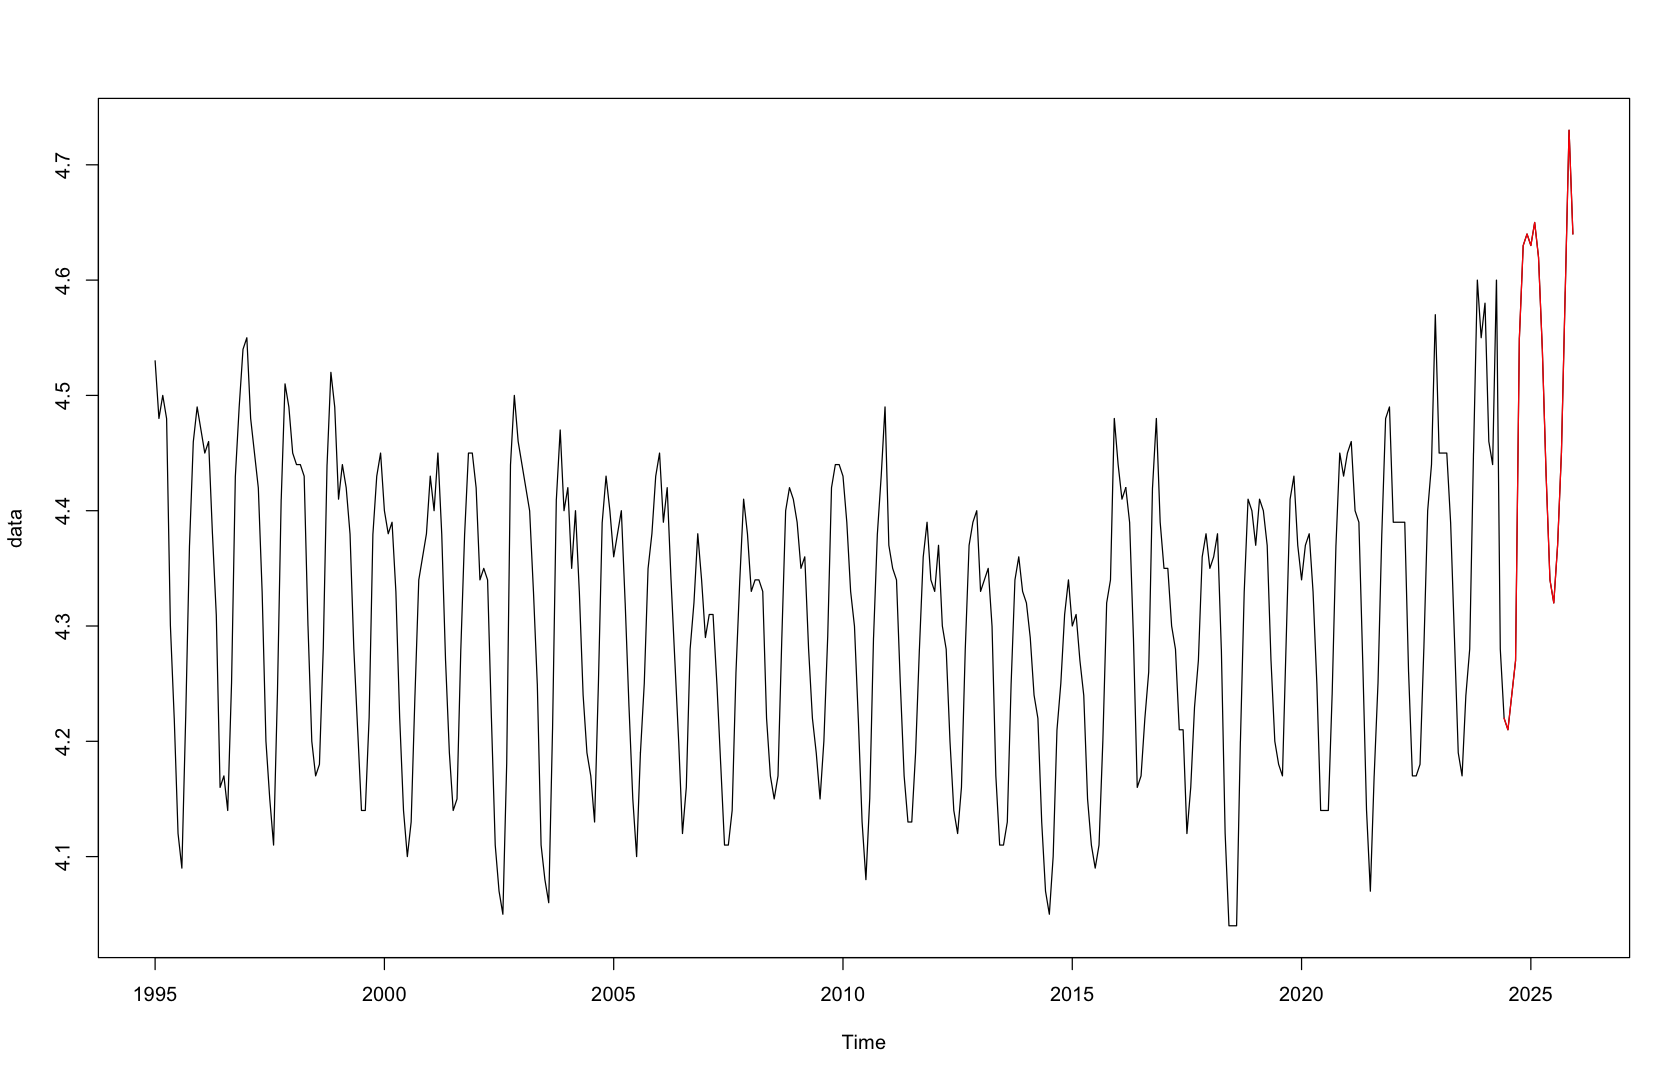

In [6]:
plot(data)
lines(data_test, col = 'red')

***

## Check ACF and PACF

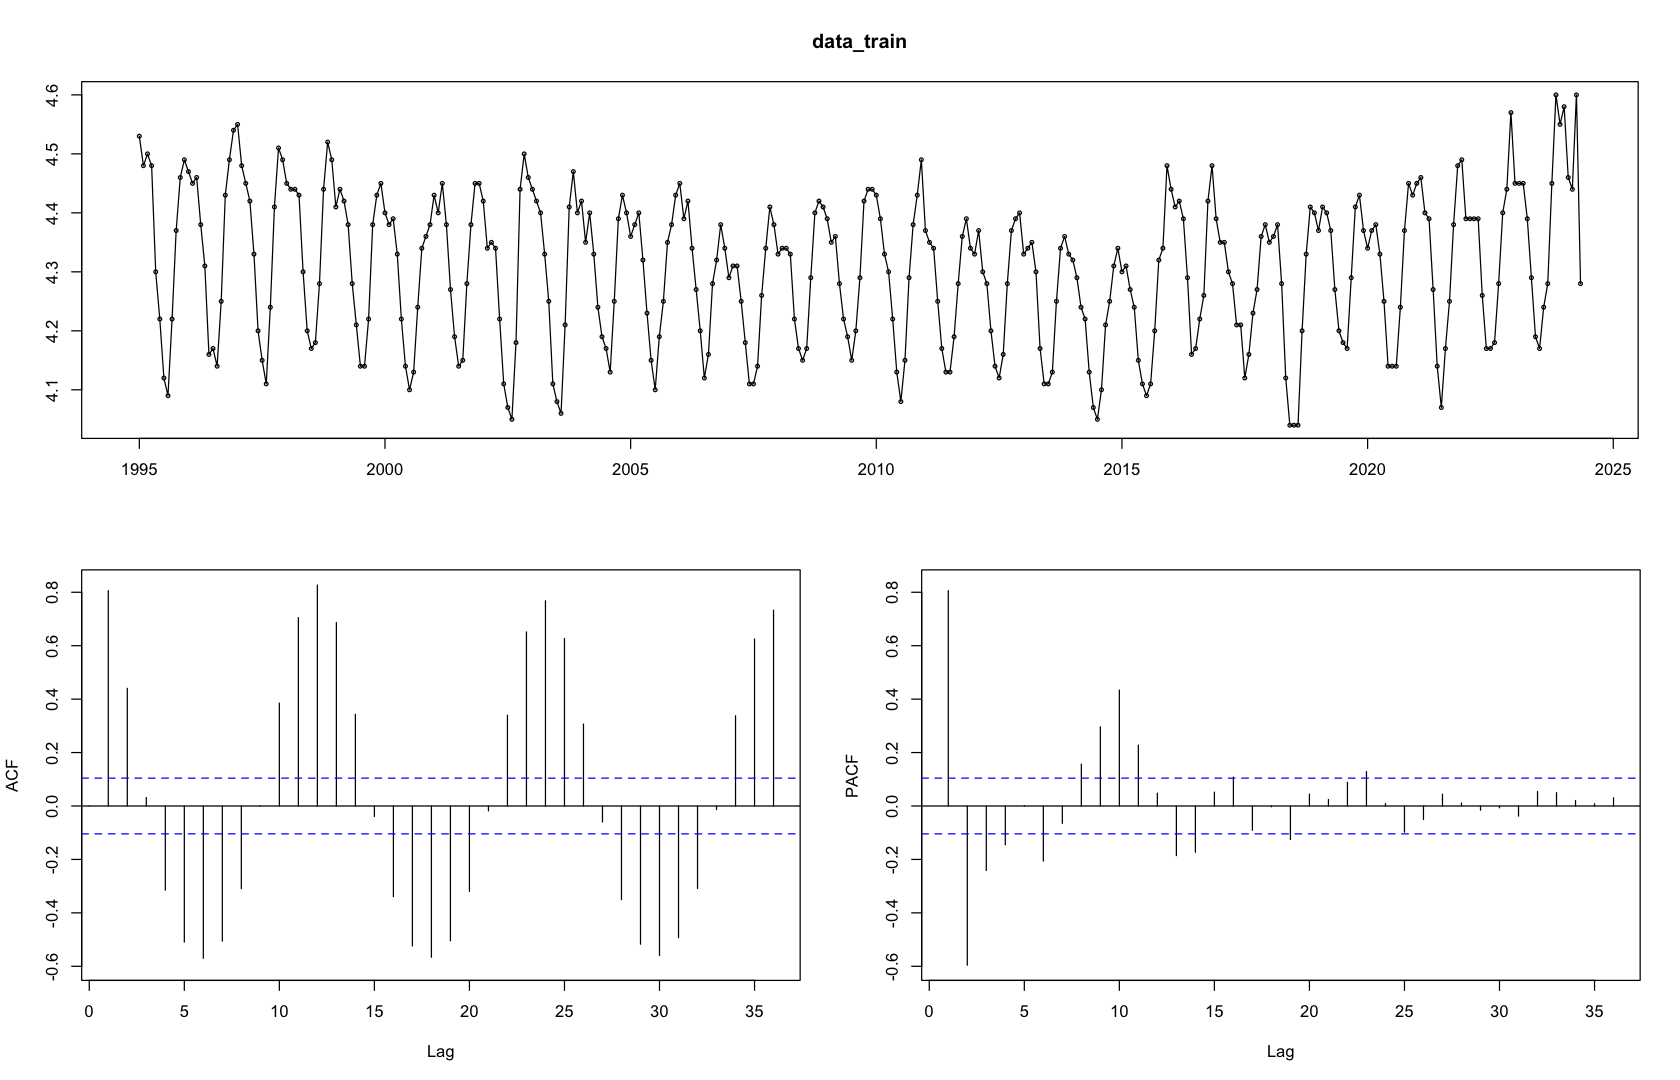

In [7]:
tsdisplay(data_train)

## Test for stationarity

In [8]:
library(tseries)

adf.test(data_train)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Warning message in adf.test(data_train):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  data_train
Dickey-Fuller = -7.6441, Lag order = 7, p-value = 0.01
alternative hypothesis: stationary


## Test for seasonality

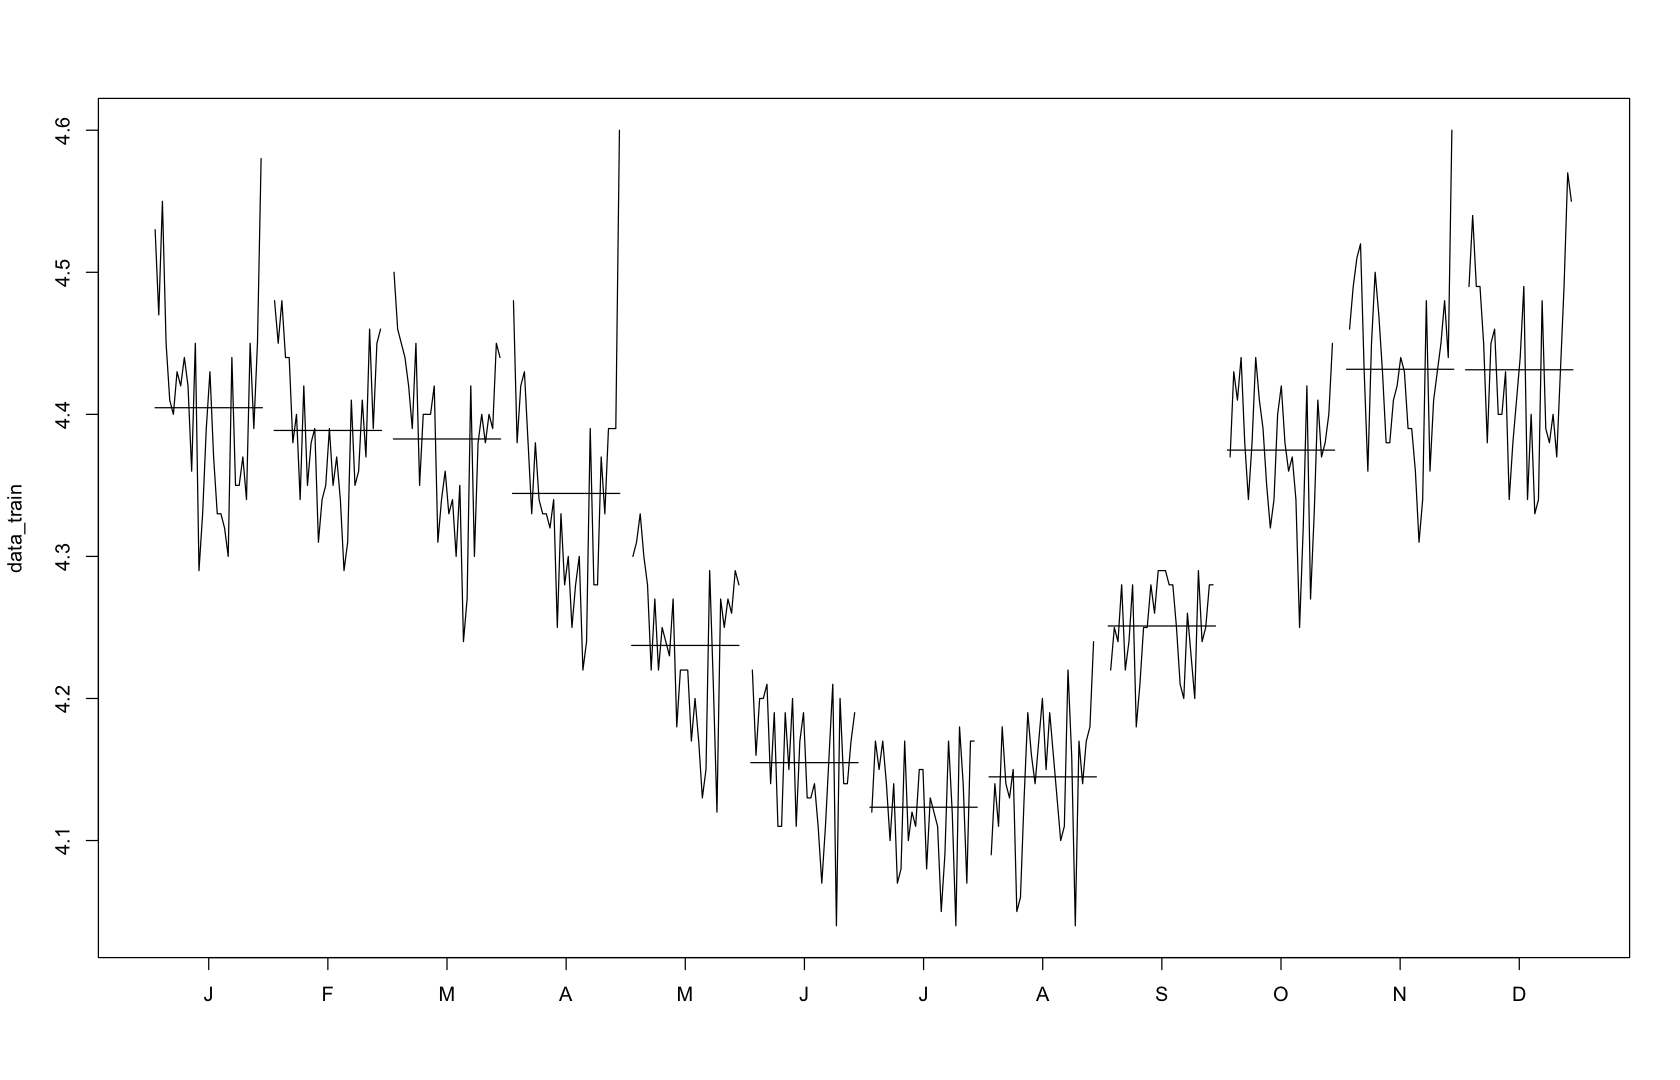

In [9]:
monthplot(data_train)

## Time series is stationary with a strong seasonal trend, which dominates the variability of the signal

***

## Seasonal-Trend decomposition using LOESS (STL)

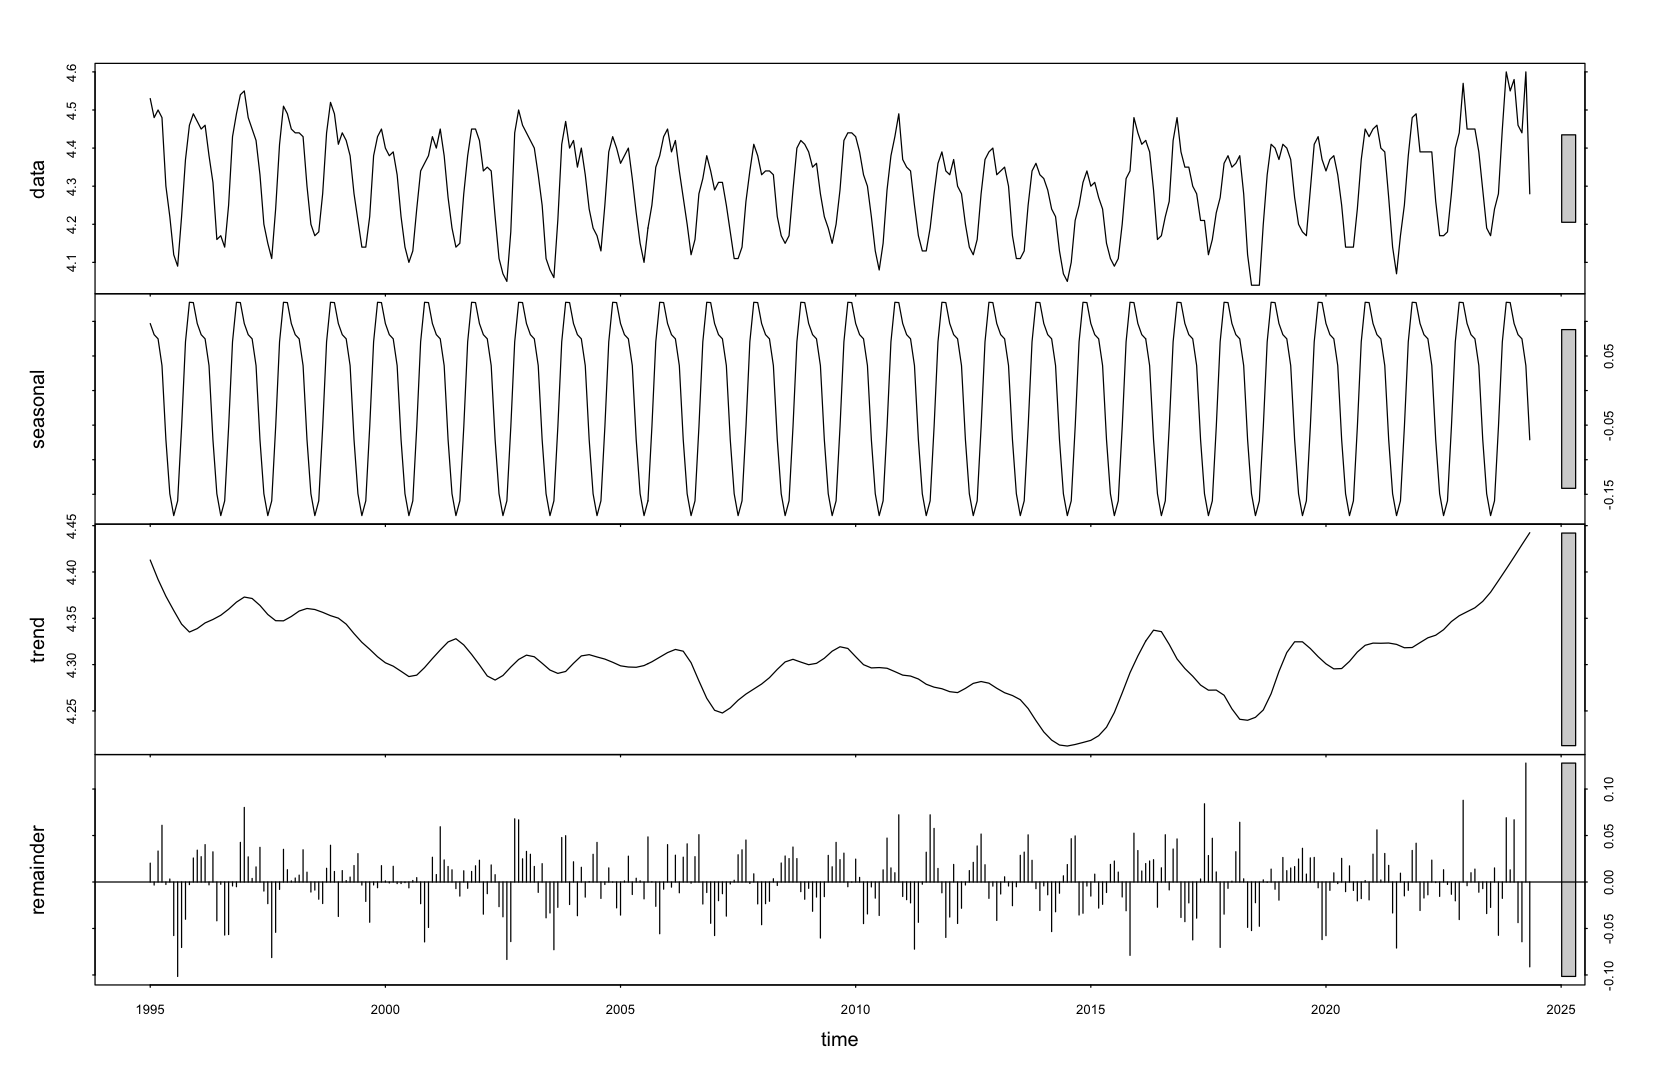

In [10]:
decomposed = stl(data_train, s.window = "periodic")

plot(decomposed)

In [11]:
forecast_stl_arima = stlf(
                        data_train, 
                        method = "arima",
                        h = n - n_train,
                        level = c(80, 95),
                        )


	Ljung-Box test

data:  Residuals from STL +  ARIMA(3,1,5)
Q* = 29.778, df = 16, p-value = 0.01919

Model df: 8.   Total lags used: 24



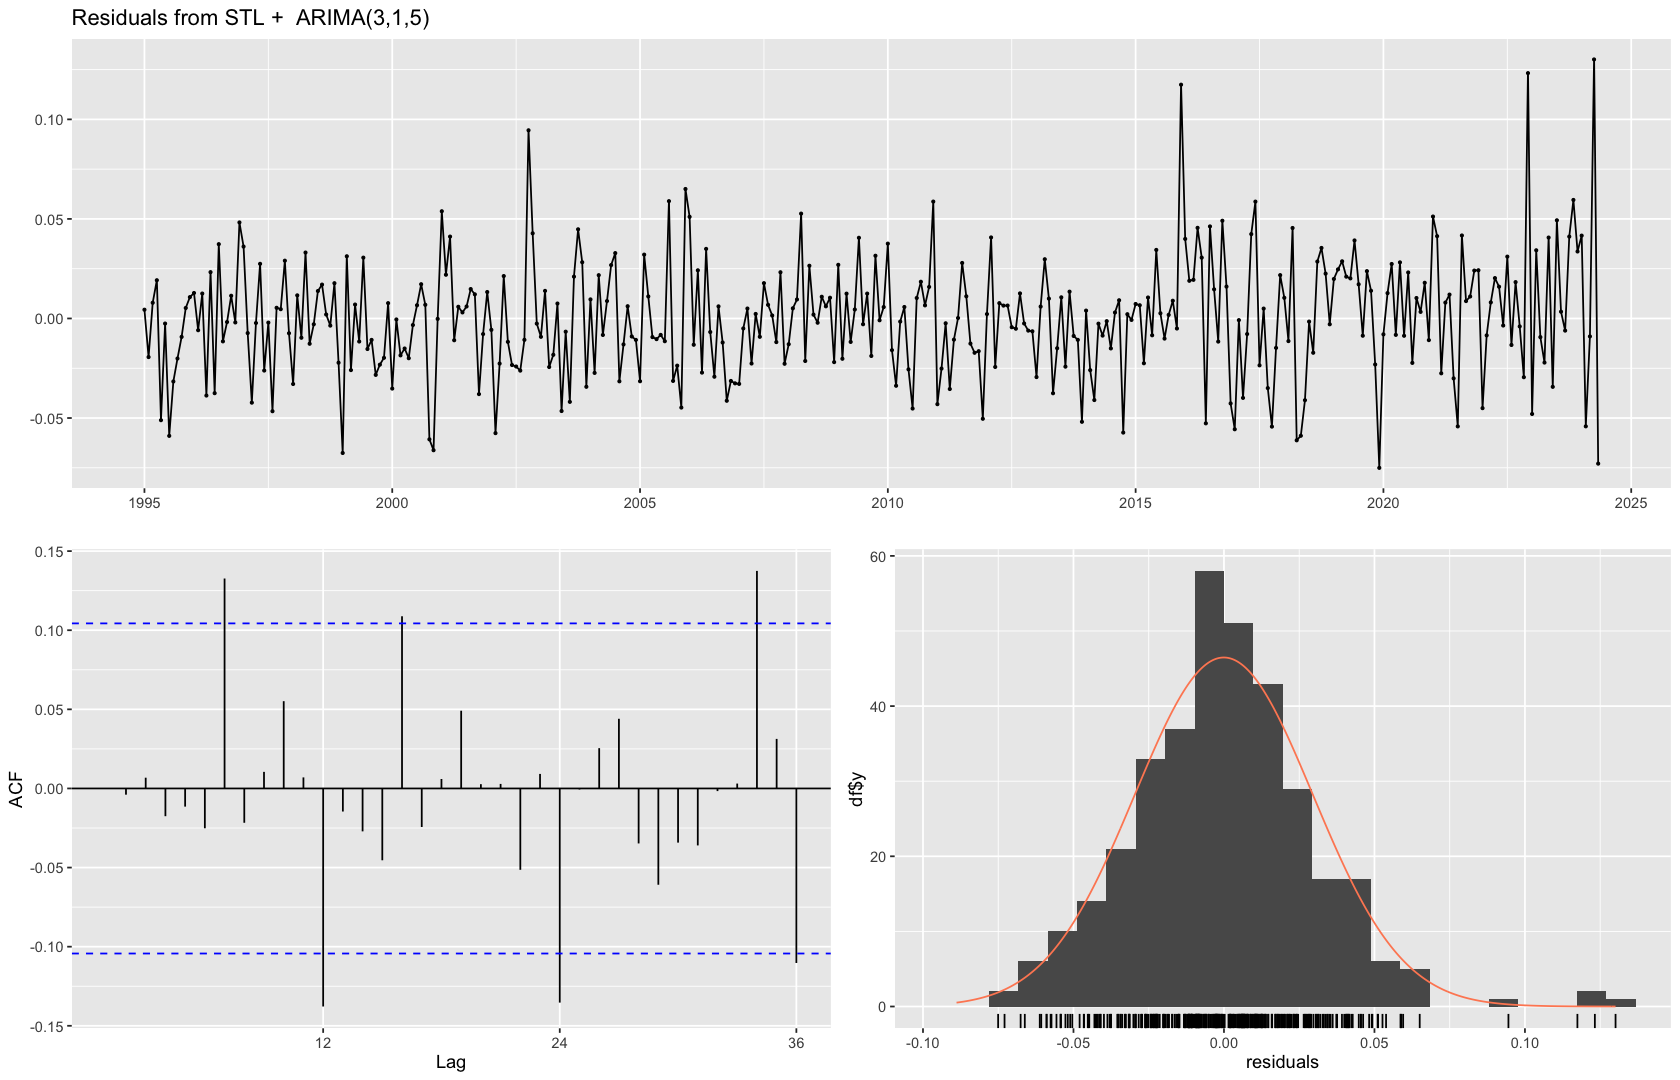

In [12]:
checkresiduals(forecast_stl_arima)

### compare raw data (black) vs. fitted model (red)

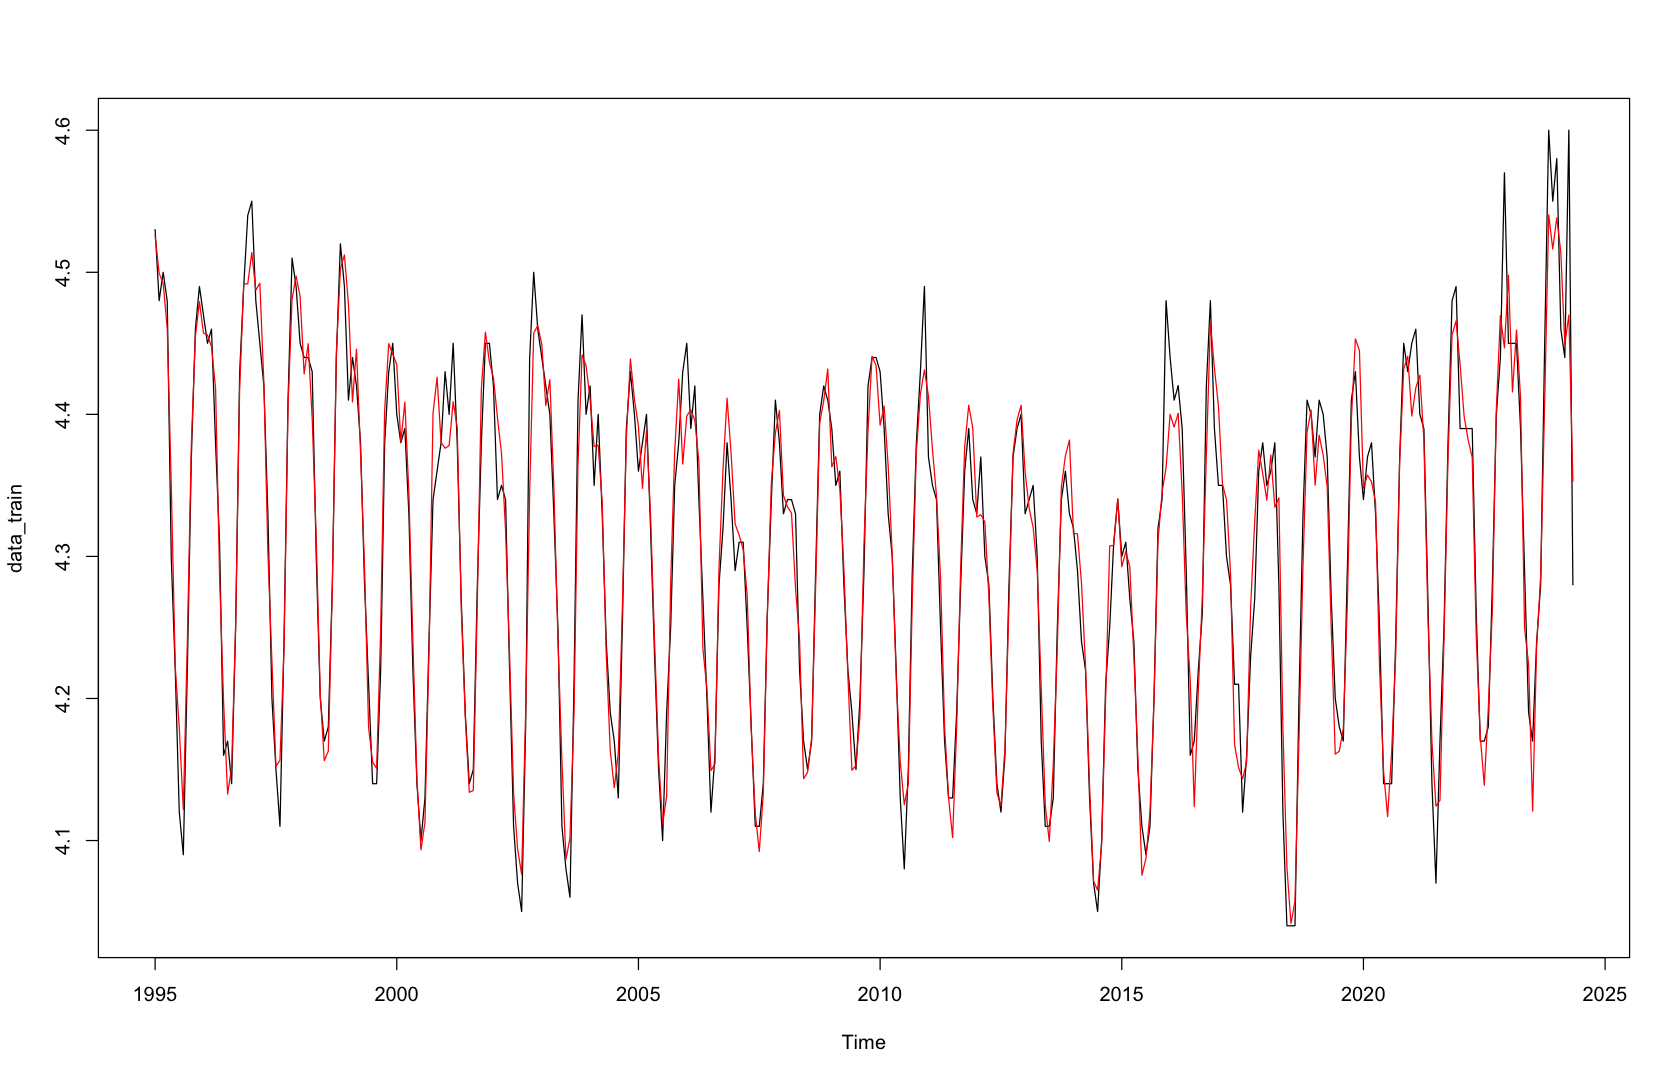

In [13]:
plot(data_train, type = "l")
lines(forecast_stl_arima$fitted, col = "red")

### forecast fitted STL-ARIMA model

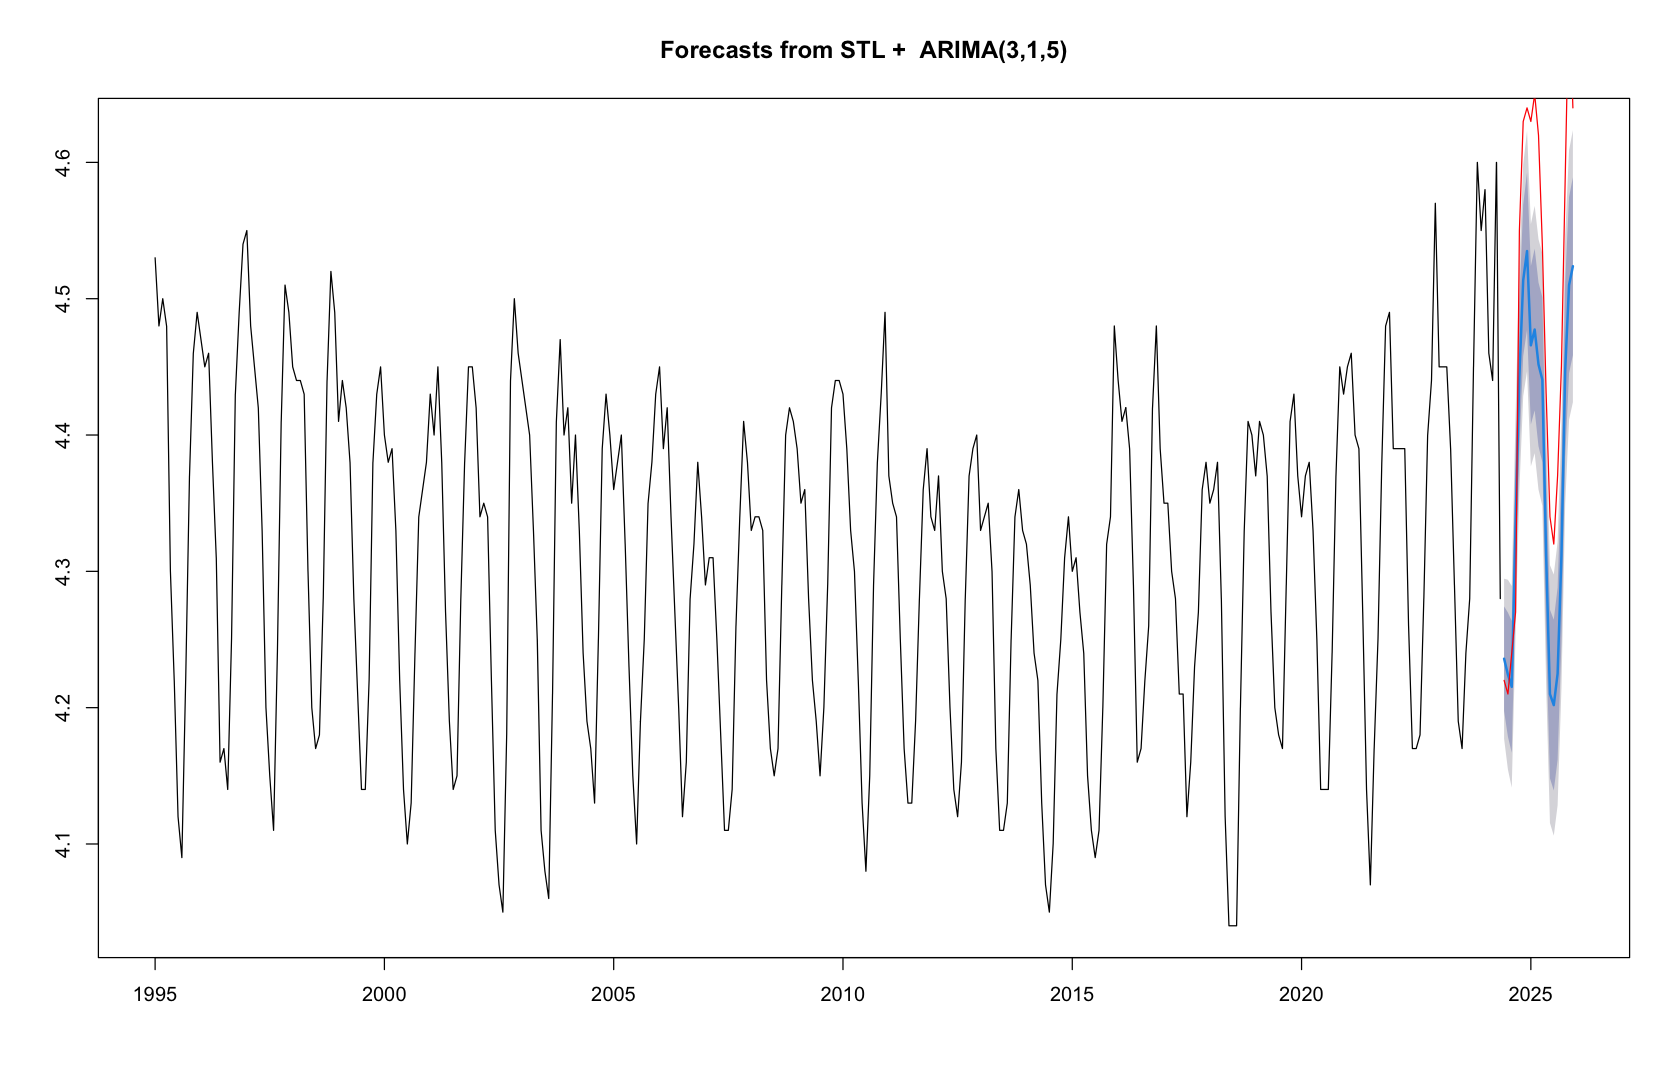

In [14]:
plot(forecast_stl_arima)
lines(data_test, col = 'red')

***

## ETS-model

In [15]:
ets_model <- ets(data_train)

ets_model

ETS(M,A,M) 

Call:
ets(y = data_train)

  Smoothing parameters:
    alpha = 0.6259 
    beta  = 0.0021 
    gamma = 1e-04 

  Initial states:
    l = 4.42 
    b = 1e-04 
    s = 1.0298 1.0298 1.0167 0.9878 0.9625 0.9571
           0.9652 0.9834 1.0081 1.0177 1.0192 1.0226

  sigma:  0.0089

      AIC      AICc       BIC 
-216.2779 -214.4511 -150.5480 


	Ljung-Box test

data:  Residuals from ETS(M,A,M)
Q* = 58.824, df = 24, p-value = 9.343e-05

Model df: 0.   Total lags used: 24



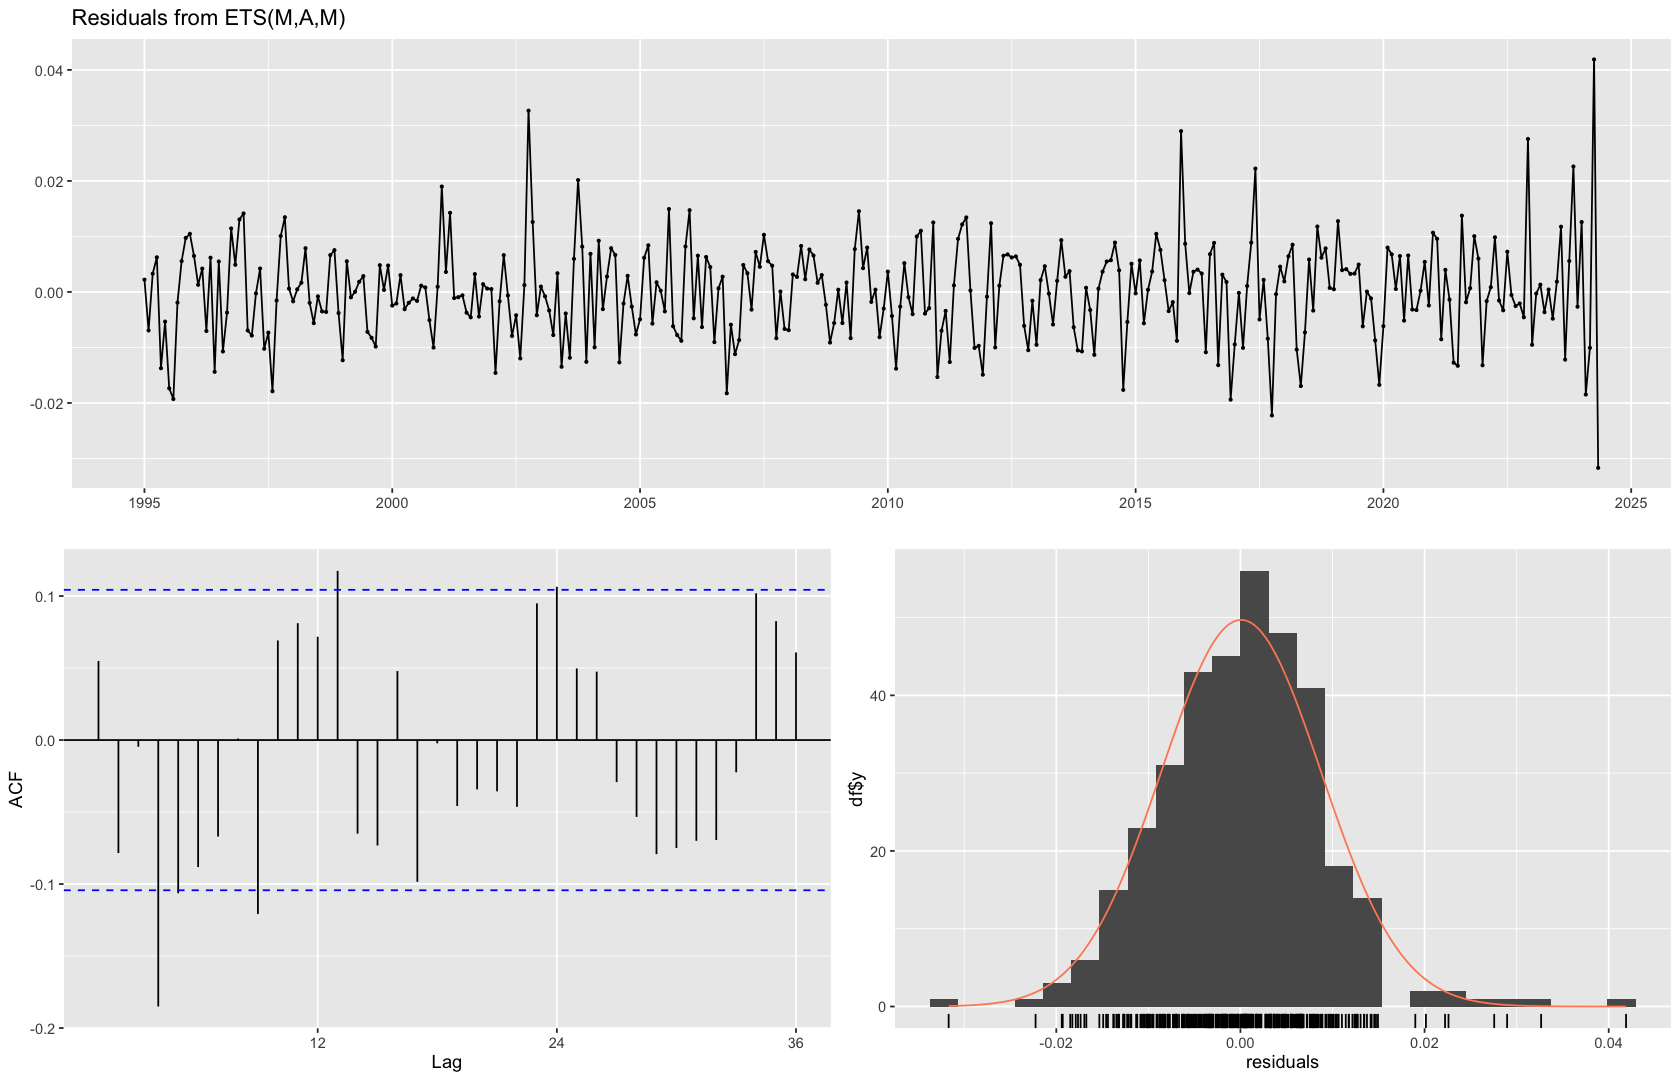

In [16]:
checkresiduals(ets_model)

### compare raw data (black) vs. fitted model (red)

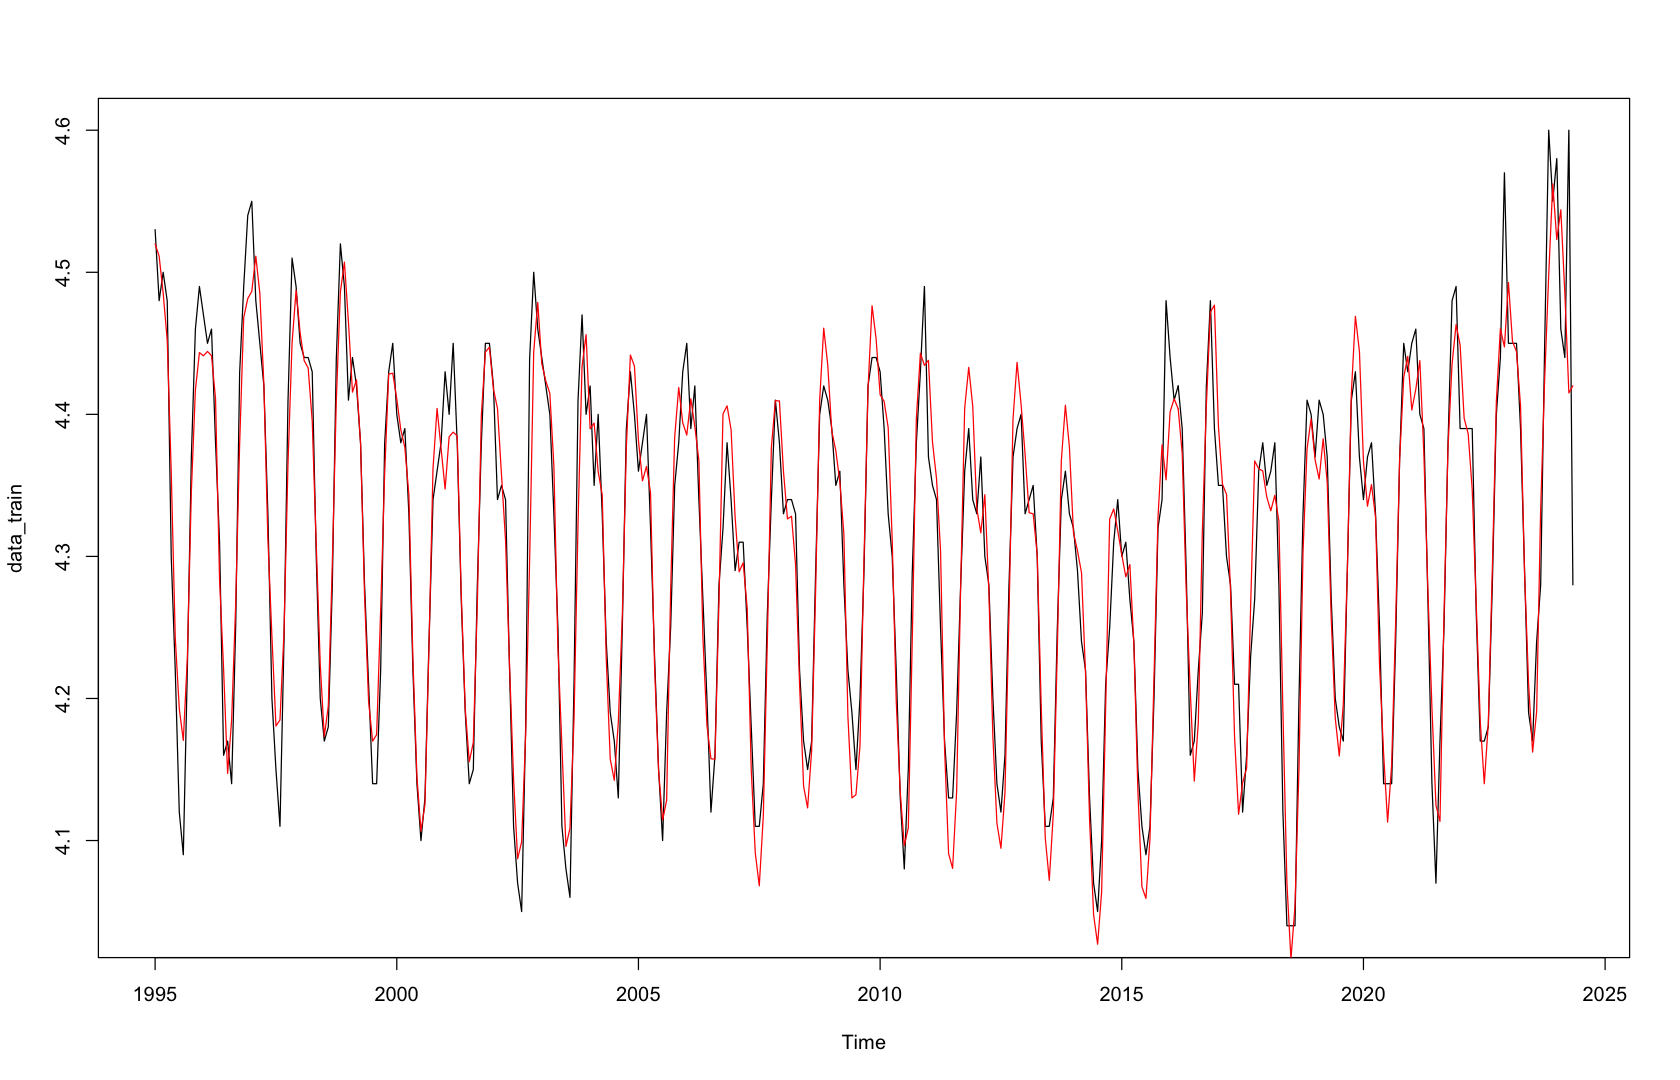

In [17]:
plot(data_train, type = "l")
lines(ets_model$fitted, col = "red")

### forecast fitted ETS model

In [18]:
forecast_ets <- forecast(ets_model, h = n - n_train) 

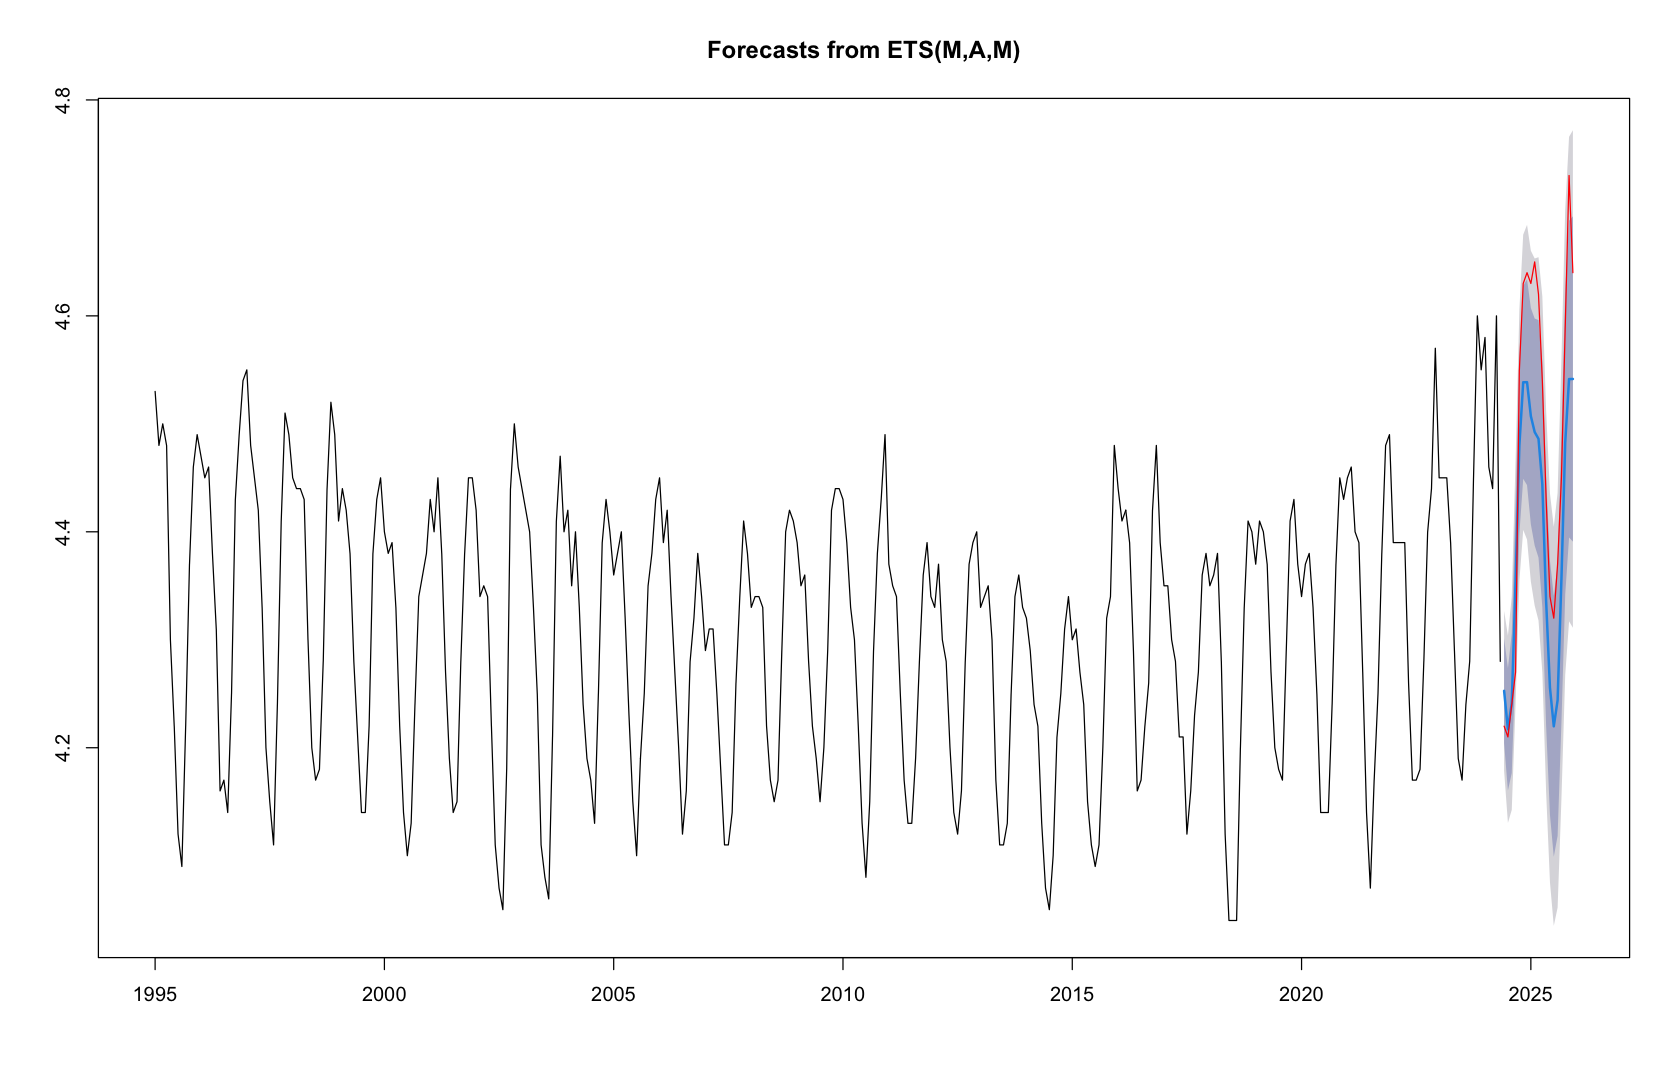

In [19]:
plot(forecast_ets)
lines(data_test, col = 'red')

## Compare accuracies of STL-ARIMA vs. ETS models

In [20]:
accuracy(forecast_stl_arima, data_test)
accuracy(forecast_ets, data_test)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-4.842227e-05,0.02956036,0.02241894,-0.00612113,0.5188193,0.4906842,-0.0002396687,NA
Test set,1.048583e-01,0.12635100,0.11474105,2.29920841,2.5316180,2.5113413,0.5759531304,1.293506


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,0.0002175992,0.03755833,0.02840065,0.0002139857,0.6582692,0.6216061,0.04787836,NA
Test set,0.0811762796,0.10415470,0.09421945,1.7722388835,2.0789238,2.0621843,0.59713995,1.062547


***

# Summary:
- ETS model outperforms the STL-ARIMA model by essentially every relevant test-set measure. 
- A high autocorrelation of residuals in the test set for both models, which indicates how the two models failed to explain patterns in the test data. Adjustment of the models is likely needed to increase performance.

***